In [1]:
import pandas as pd
import matplotlib.pyplot as plt
columns = [
    "Variance",
    "Skewness",
    "Curtosis",
    "Entropy",
    "Class"
]
data = "https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt"
df = pd.read_csv(data, header=None, names=columns)
print(df.head())

   Variance  Skewness  Curtosis  Entropy  Class
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0


In [2]:
print("\n========== Dataset Dimensions ==========")
print(f"Shape   : {df.shape}")


========== Dataset Dimensions ==========
Shape   : (1372, 5)


In [3]:
print("\n========== Missing Values ==========")
print(df.isnull().sum())


========== Missing Values ==========
Variance    0
Skewness    0
Curtosis    0
Entropy     0
Class       0
dtype: int64


In [4]:
print("\n========== Descriptive Statistics ==========")
print(df.describe())


========== Descriptive Statistics ==========
          Variance     Skewness     Curtosis      Entropy        Class
count  1372.000000  1372.000000  1372.000000  1372.000000  1372.000000
mean      0.433735     1.922353     1.397627    -1.191657     0.444606
std       2.842763     5.869047     4.310030     2.101013     0.497103
min      -7.042100   -13.773100    -5.286100    -8.548200     0.000000
25%      -1.773000    -1.708200    -1.574975    -2.413450     0.000000
50%       0.496180     2.319650     0.616630    -0.586650     0.000000
75%       2.821475     6.814625     3.179250     0.394810     1.000000
max       6.824800    12.951600    17.927400     2.449500     1.000000


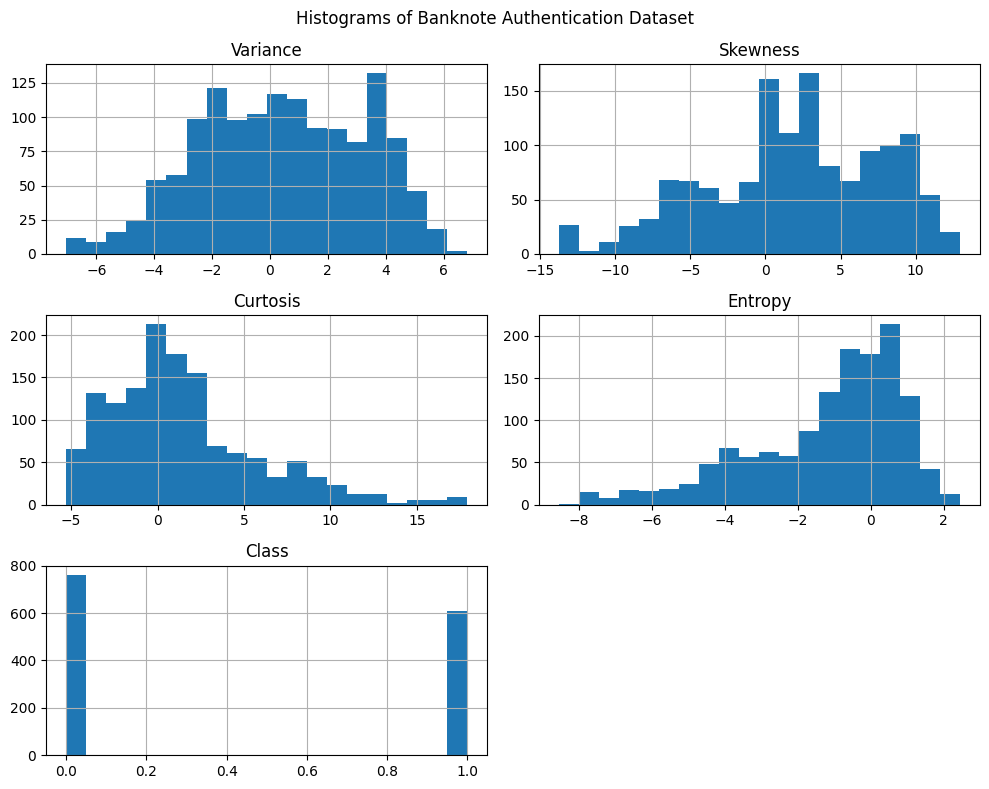

In [5]:

df.hist(figsize=(10, 8), bins=20)

plt.suptitle("Histograms of Banknote Authentication Dataset")
plt.tight_layout()
plt.show()

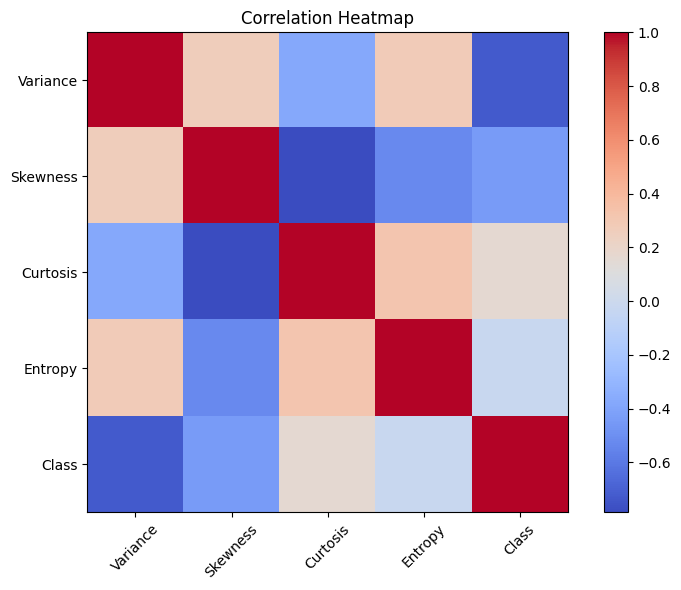

In [6]:
# Correlation Heatmap
correlation = df.corr()

plt.figure(figsize=(8, 6))
plt.imshow(correlation, cmap="coolwarm", interpolation="nearest")
plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

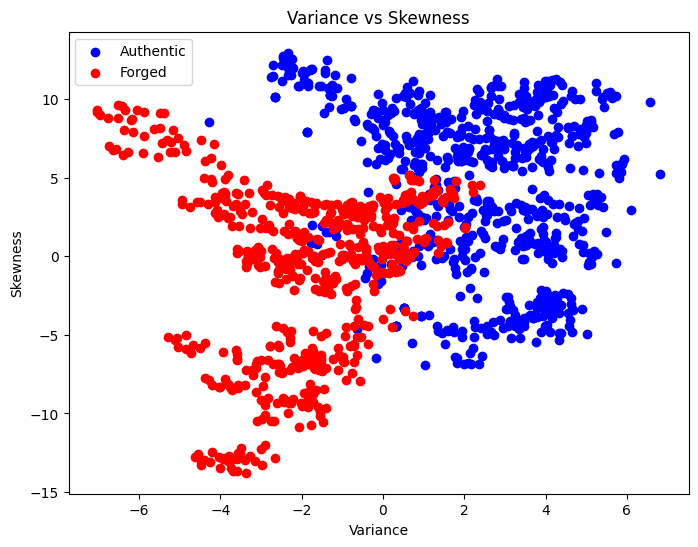

In [7]:
# Scatter Plot
plt.figure(figsize=(8,6))

plt.scatter(
    df[df["Class"] == 0]["Variance"],
    df[df["Class"] == 0]["Skewness"],
    color="blue",
    label="Authentic"
)

plt.scatter(
    df[df["Class"] == 1]["Variance"],
    df[df["Class"] == 1]["Skewness"],
    color="red",
    label="Forged"
)

plt.xlabel("Variance")
plt.ylabel("Skewness")
plt.title("Variance vs Skewness")
plt.legend()
plt.show()

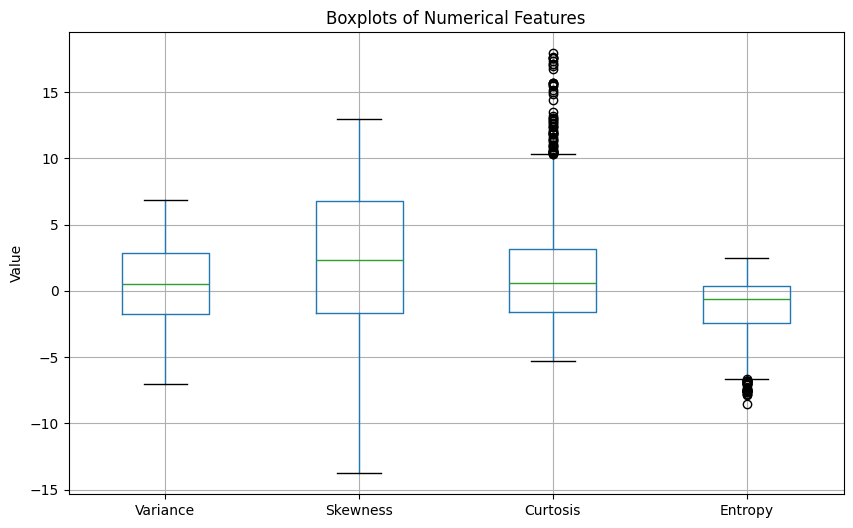

In [8]:
# Boxplots
plt.figure(figsize=(10,6))

df.drop("Class", axis=1).boxplot()

plt.title("Boxplots of Numerical Features")
plt.ylabel("Value")
plt.show()

In [9]:
# Features (Input)
X = df.drop("Class", axis=1)

# Target (Output)
y = df["Class"]
# print(X_scaled[:5])

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [11]:
# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42
)



In [13]:
# SCRATCH IMPLEMENTATION
import numpy as np

class Perceptron:

    def __init__(self, learning_rate=0.01, epochs=10):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None

    # Step Activation Function
    def activation(self, x):
        return 1 if x >= 0 else 0

    # Forward Propagation
    def predict(self, x):
        linear_output = np.dot(x, self.weights) + self.bias
        return self.activation(linear_output)

    def fit(self, X, y):

        n_samples, n_features = X.shape

        # Weight Initialization
        self.weights = np.zeros(n_features)

        # Bias Initialization
        self.bias = 0

        # Print table header
        print(f"{'Epoch':<8}{'Errors':<8}{'Weight 1':<12}{'Weight 2':<12}{'Bias':<10}")

        for epoch in range(self.epochs):

            errors = 0

            for i in range(n_samples):

                prediction = self.predict(X[i])
                error = y.iloc[i] - prediction

                # Update only if prediction is wrong
                if error != 0:
                    self.weights += self.learning_rate * error * X[i]
                    self.bias += self.learning_rate * error
                    errors += 1

            # Print epoch summary
            print(f"{epoch+1:<8}{errors:<8}{self.weights[0]:<12.4f}{self.weights[1]:<12.4f}{self.bias:<10.4f}")

In [14]:
perceptron = Perceptron(learning_rate=0.01, epochs=10)

perceptron.fit(X_train, y_train)

Epoch   Errors  Weight 1    Weight 2    Bias      
1       47      -0.0725     -0.0649     -0.0300   
2       26      -0.0822     -0.0938     -0.0300   
3       34      -0.0947     -0.0914     -0.0500   
4       23      -0.1107     -0.0958     -0.0400   
5       27      -0.1310     -0.1218     -0.0500   
6       25      -0.1395     -0.1284     -0.0400   
7       19      -0.1353     -0.1404     -0.0500   
8       19      -0.1335     -0.1448     -0.0600   
9       16      -0.1343     -0.1318     -0.0600   
10      26      -0.1317     -0.1558     -0.0600   


In [15]:
# Predict on test data
y_pred = []

for x in X_test:
    prediction = perceptron.predict(x)
    y_pred.append(prediction)

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Predict on test data
y_pred = []

for sample in X_test:
    y_pred.append(perceptron.predict(sample))

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

# Display results
print("Scratch-implementation")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

print("\nConfusion Matrix:")
print(cm)

Scratch-implementation
Accuracy : 0.9781818181818182
Precision: 0.984
Recall   : 0.968503937007874
F1-Score : 0.9761904761904762

Confusion Matrix:
[[146   2]
 [  4 123]]


In [17]:
#  built in
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Train sklearn Perceptron
sk_model = Perceptron(max_iter=1000, eta0=0.01, random_state=42)
sk_model.fit(X_train, y_train)

# Predictions
y_pred_sk = sk_model.predict(X_test)

# Evaluation
print("Scikit-learn Perceptron")
print("Accuracy :", accuracy_score(y_test, y_pred_sk))
print("Precision:", precision_score(y_test, y_pred_sk))
print("Recall   :", recall_score(y_test, y_pred_sk))
print("F1-score :", f1_score(y_test, y_pred_sk))

Scikit-learn Perceptron
Accuracy : 0.9890909090909091
Precision: 0.9769230769230769
Recall   : 1.0
F1-score : 0.9883268482490273


In [18]:
# DIFFERENT LEARNING RATES
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

learning_rates = [0.001, 0.01, 0.1]

for lr in learning_rates:

    model = Perceptron(
        eta0=lr,          # Learning rate
        max_iter=1000,
        tol=1e-3,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print(f"\nLearning Rate: {lr}")
    print(f"Accuracy : {accuracy_score(y_test, y_pred)}")
    print(f"Precision: {precision_score(y_test, y_pred)}")
    print(f"Recall   : {recall_score(y_test, y_pred)}")
    print(f"F1-score : {f1_score(y_test, y_pred)}")


Learning Rate: 0.001
Accuracy : 0.9890909090909091
Precision: 0.9769230769230769
Recall   : 1.0
F1-score : 0.9883268482490273

Learning Rate: 0.01
Accuracy : 0.9890909090909091
Precision: 0.9769230769230769
Recall   : 1.0
F1-score : 0.9883268482490273

Learning Rate: 0.1
Accuracy : 0.9781818181818182
Precision: 0.9689922480620154
Recall   : 0.984251968503937
F1-score : 0.9765625
